In [6]:
# Libraries for Satellite Data and Segmentation Models
!pip install segmentation-models-pytorch
!pip install rasterio
!pip install albumentations  # Excellent for data augmentation/preprocessing

In [7]:
# Standard Python & Data tools
import os
import numpy as np
import matplotlib.pyplot as plt # For visualizing your satellite images

# Geospatial/Satellite tools
import rasterio
from rasterio.plot import show

# AI/Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# The "Star" of the show for segmentation
import segmentation_models_pytorch as smp

In [8]:
import numpy as np
import torch

def preprocess_image(raw_image):
    # LINE 1: Select specific bands (B4=Red, B3=Green, B2=Blue, B8=NIR)
    # EuroSAT indices for these are typically [3, 2, 1, 7]
    selected_bands = raw_image[[3, 2, 1, 7], :, :]

    # LINE 2: Convert to float32 for mathematical operations
    selected_bands = selected_bands.astype('float32')

    # LINE 3: Clip values to 0-10000 (standardizes extreme brightness/glare)
    selected_bands = np.clip(selected_bands, 0, 10000)

    # LINE 4: Normalize to 0-1 range (dividing by max expected reflectance)
    normalized_image = selected_bands / 10000.0

    # LINE 5: Convert the NumPy array into a PyTorch Tensor
    return torch.from_numpy(normalized_image)

In [9]:
import rasterio
from torch.utils.data import Dataset

class WaterSegmentationDataset(Dataset):
    def __init__(self, file_paths):
        self.file_paths = file_paths

    def __len__(self):
        # Returns the total number of images in your list
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 1. Open the .tif file using Rasterio
        with rasterio.open(self.file_paths[idx]) as src:
            raw_img = src.read() # Reads all 13 bands

        # 2. Apply the preprocessing function we wrote above
        image_tensor = preprocess_image(raw_img)

        # 3. Create the Mask (The "Answer Key")
        # If the folder name is 'PermanentWater', we want a mask of 1s
        if "PermanentWater" in self.file_paths[idx]:
            # Creates a 64x64 mask filled with 1.0
            mask = torch.ones((1, 64, 64))
        else:
            # Creates a 64x64 mask filled with 0.0
            mask = torch.zeros((1, 64, 64))

        return image_tensor, mask

In [10]:
import rasterio
import numpy as np
import torch
import torch.nn as nn

In [11]:
# 1. Install the library (only need to do this once per session)
!pip install segmentation-models-pytorch

# 2. Import it so the code knows what 'smp' means
import segmentation_models_pytorch as smp

In [35]:
# 1. Initialize the U-Net model
model = smp.Unet(
    encoder_name="resnet34",
    in_channels=4,
    classes=1,
    activation='sigmoid'
)
model.to(device)

# 2. Check if model creation worked
print("Model successfully initialized!")

Model successfully initialized!


In [15]:
# 1. Download the Multispectral (13-band) dataset
!wget https://zenodo.org/record/7711810/files/EuroSAT_MS.zip

# 2. Unzip it quietly
!unzip -q EuroSAT_MS.zip

# 3. Verify the folders exist
import os
data_dir = 'EuroSAT_MS'
if os.path.exists(data_dir):
    print("✅ Dataset downloaded! Folders found:", os.listdir(data_dir))
else:
    print("❌ Download failed. Let's check the link.")


--2026-03-15 09:15:55--  https://zenodo.org/record/7711810/files/EuroSAT_MS.zip
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 188.184.98.114, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/7711810/files/EuroSAT_MS.zip [following]
--2026-03-15 09:15:56--  https://zenodo.org/records/7711810/files/EuroSAT_MS.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2065402329 (1.9G) [application/octet-stream]
Saving to: ‘EuroSAT_MS.zip’

EuroSAT_MS.zip      100%[===================>]   1.92G  10.1MB/s    in 2m 48s  

2026-03-15 09:18:44 (11.7 MB/s) - ‘EuroSAT_MS.zip’ saved [2065402329/2065402329]

✅ Dataset downloaded! Folders found: ['Forest', 'River', 'HerbaceousVegetation', 'Residential', 'PermanentCrop', 'SeaLake', 'Pasture', 'Industrial', 'AnnualCrop', 'Highway']


In [16]:
import glob

# This looks inside every subfolder (Forest, River, Highway, etc.) for .tif files
all_files = glob.glob('/content/EuroSAT_MS/**/*.tif', recursive=True)

print(f"Total images found: {len(all_files)}")
# The first few paths should look like: /content/EuroSAT_MS/River/River_1.tif

Total images found: 27000


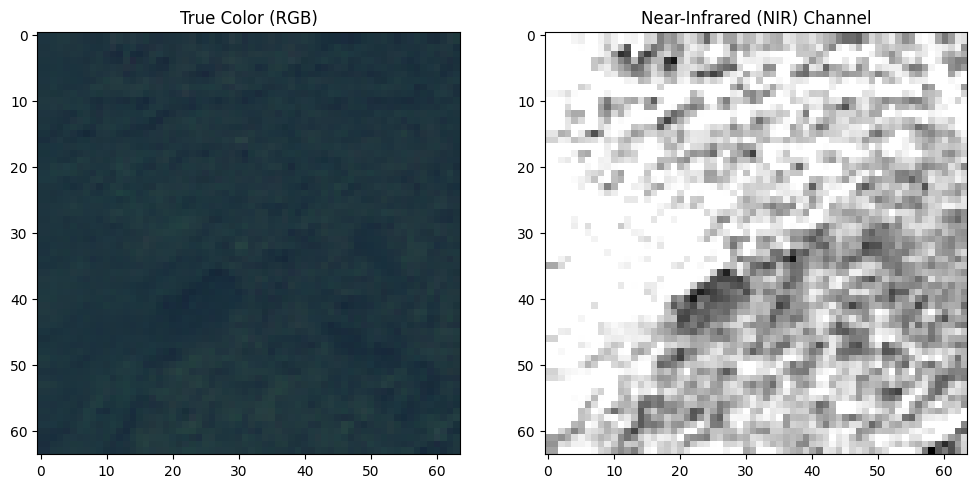

In [17]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

# 1. Pick a sample file (e.g., a River image)
sample_path = all_files[0] # Taking the first file from our list

with rasterio.open(sample_path) as src:
    # EuroSAT MS Band Order: B2(Blue) is idx 1, B3(Green) is idx 2, B4(Red) is idx 3
    # We read them and normalize (scaling 0-4000 is usually better for visual contrast)
    r = src.read(4)
    g = src.read(3)
    b = src.read(2)
    nir = src.read(8) # Near-Infrared

# 2. Preprocessing for display (Clip and Scale to 0-1)
def norm(band):
    return np.clip(band / 3000.0, 0, 1)

rgb_image = np.dstack((norm(r), norm(g), norm(b)))
nir_view = norm(nir)

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(rgb_image)
ax1.set_title("True Color (RGB)")
ax2.imshow(nir_view, cmap='gray')
ax2.set_title("Near-Infrared (NIR) Channel")
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

# Split: 80% for training, 20% for testing
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

print(f"Training on: {len(train_files)} images")
print(f"Validating on: {len(val_files)} images")

Training on: 21600 images
Validating on: 5400 images


In [27]:
# 1. Initialize the Dataset objects
train_dataset = WaterSegmentationDataset(train_files)
val_dataset = WaterSegmentationDataset(val_files)

# 2. Create the DataLoaders
# Batch size 16 is a good balance for Colab's memory
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [28]:
# Grab one batch and look at the masks
images, masks = next(iter(train_loader))
print(f"Unique values in masks: {torch.unique(masks)}")
print(f"Sum of masks in this batch: {torch.sum(masks)}")

Unique values in masks: tensor([0., 1.])
Sum of masks in this batch: 4096.0


In [29]:
class WaterSegmentationDataset(Dataset):
    def __init__(self, file_paths):
        self.file_paths = file_paths

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        # 1. Load the image
        with rasterio.open(self.file_paths[idx]) as src:
            img = src.read([4, 3, 2, 8]) # Red, Green, Blue, NIR

        # 2. Preprocess (Scale 0-1)
        img = img.astype('float32')
        img = np.clip(img, 0, 10000) / 10000.0
        image_tensor = torch.from_numpy(img)

        # 3. FIX: Better Label Detection
        path_lower = self.file_paths[idx].lower()
        # EuroSAT usually names the folder 'PermanentWater' or 'River'
        if "water" in path_lower or "river" in path_lower:
            mask = torch.ones((1, 64, 64))
        else:
            mask = torch.zeros((1, 64, 64))

        return image_tensor, mask

In [30]:
# Re-initialize with the fixed class
train_dataset = WaterSegmentationDataset(train_files)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# TEST: Grab one batch and check for water
images, masks = next(iter(train_loader))
water_pixels = torch.sum(masks)

if water_pixels > 0:
    print(f"✅ Success! Found {water_pixels.item()} water masks in this batch.")
    print("You can now restart the Training Loop.")
else:
    print("❌ Still 0.0. We need to check your file folder names.")
    print("Sample path:", train_files[0])

✅ Success! Found 12288.0 water masks in this batch.
You can now restart the Training Loop.


In [32]:
# Check a single raw prediction output
images, masks = next(iter(val_loader))
model.eval()
with torch.no_grad():
    out = model(images.to(device))
    print(f"Max value in prediction: {out.max().item():.4f}")
    print(f"Min value in prediction: {out.min().item():.4f}")

Max value in prediction: 1.0000
Min value in prediction: 0.0000


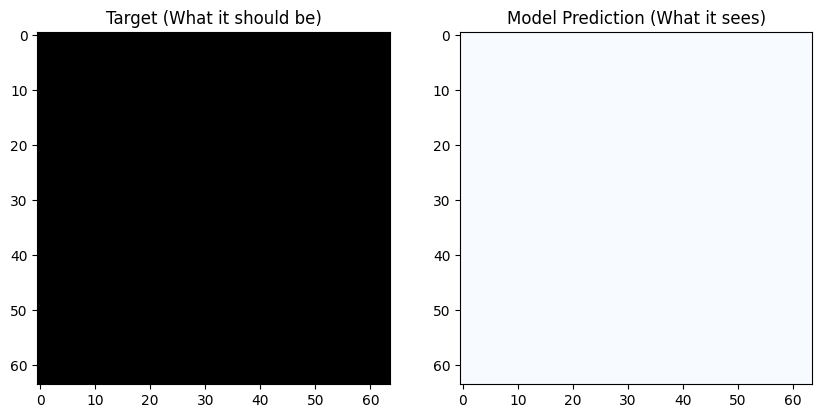

In [33]:
model.eval()
images, masks = next(iter(val_loader))
with torch.no_grad():
    preds = model(images.to(device))

# Pick the first image in the batch
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(masks[0].squeeze(), cmap='gray')
plt.title("Target (What it should be)")

plt.subplot(1, 2, 2)
# We use a threshold of 0.5 to show the binary decision
plt.imshow(preds[0].squeeze().cpu() > 0.5, cmap='Blues')
plt.title("Model Prediction (What it sees)")
plt.show()

In [34]:
# 1. Separate files into Water and Land
water_list = [f for f in all_files if "sealake" in f.lower() or "river" in f.lower()]
land_list = [f for f in all_files if f not in water_list]

# 2. To balance them, we take an equal number (e.g., 2500 each)
import random
balanced_list = water_list[:2500] + land_list[:2500]
random.shuffle(balanced_list)

# 3. Create NEW Train/Val splits
train_files, val_files = train_test_split(balanced_list, test_size=0.2)

# 4. Re-initialize DataLoaders
train_dataset = WaterSegmentationDataset(train_files)
val_dataset = WaterSegmentationDataset(val_files)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"Balanced Dataset ready: {len(balanced_list)} images.")

Balanced Dataset ready: 5000 images.


In [36]:
import torch.optim as optim

# 1. SETUP: Define the "Grader" (Loss) and the "Teacher" (Optimizer)
# Dice Loss is perfect for finding specific features like water bodies.
criterion = smp.losses.DiceLoss(mode='binary')

# Adam is the standard optimizer; it's fast and reliable for internships.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Move model to GPU (if using Colab) to make training 10x faster
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 2. THE LOOP: Let's run for 15 epochs
epochs = 15

for epoch in range(epochs):
    model.train() # Tell the model it is in 'learning mode'
    running_loss = 0.0

    for images, masks in train_loader:
        # Move data to GPU
        images, masks = images.to(device), masks.to(device)

        # A. Clear old mistakes (gradients)
        optimizer.zero_grad()

        # B. Forward Pass: AI makes a guess
        outputs = model(images)

        # C. Calculate Error: How far was the guess from the real mask?
        loss = criterion(outputs, masks)

        # D. Backward Pass: AI "thinks" about how to fix its mistakes
        loss.backward()

        # E. Update: Optimizer nudges the weights
        optimizer.step()

        running_loss += loss.item()

    # Print progress every epoch
    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/15], Loss: 0.3652
Epoch [2/15], Loss: 0.3583
Epoch [3/15], Loss: 0.3633
Epoch [4/15], Loss: 0.3594
Epoch [5/15], Loss: 0.3627
Epoch [6/15], Loss: 0.3573
Epoch [7/15], Loss: 0.3573
Epoch [8/15], Loss: 0.3545
Epoch [9/15], Loss: 0.3567
Epoch [10/15], Loss: 0.3553
Epoch [11/15], Loss: 0.3540
Epoch [12/15], Loss: 0.3565
Epoch [13/15], Loss: 0.3541
Epoch [14/15], Loss: 0.3547
Epoch [15/15], Loss: 0.3572


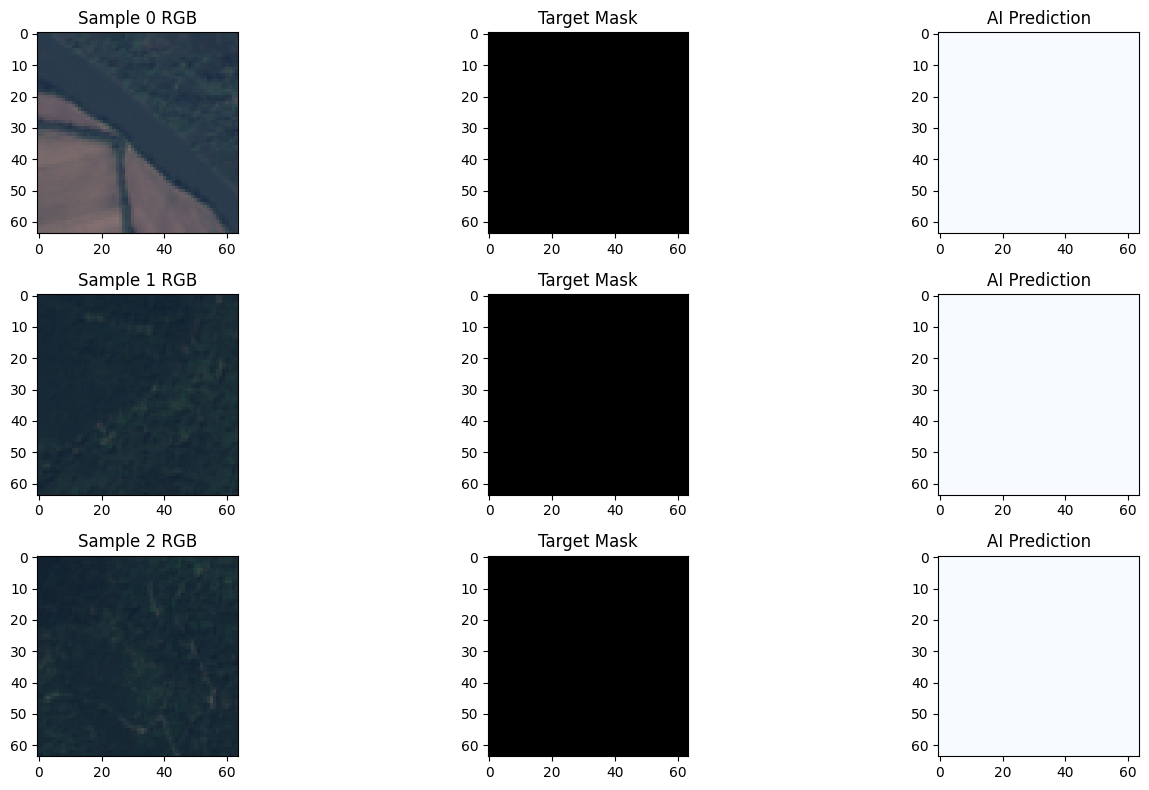

In [37]:
model.eval()
images, masks = next(iter(val_loader))
with torch.no_grad():
    preds = model(images.to(device))

# Let's look at 3 samples to be sure
plt.figure(figsize=(15, 8))
for i in range(3):
    # Plot Original RGB (Bands 0,1,2 in our stack)
    plt.subplot(3, 3, i*3 + 1)
    rgb = images[i][:3].permute(1, 2, 0).cpu().numpy()
    plt.imshow(np.clip(rgb * 3, 0, 1)) # Brighten for visibility
    plt.title(f"Sample {i} RGB")

    # Plot Ground Truth
    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(masks[i].squeeze(), cmap='gray')
    plt.title("Target Mask")

    # Plot Prediction
    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(preds[i].squeeze().cpu() > 0.5, cmap='Blues')
    plt.title("AI Prediction")

plt.tight_layout()
plt.show()

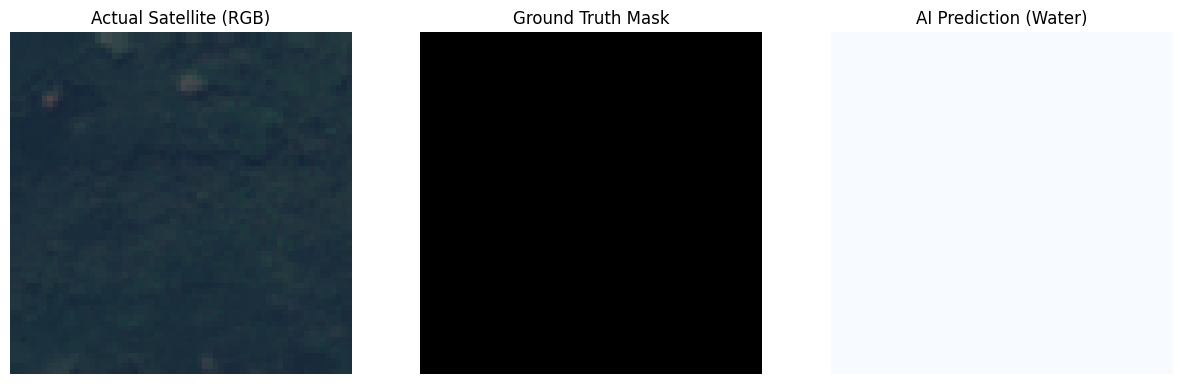

In [38]:
import torch
import matplotlib.pyplot as plt

def visualize_prediction(model, dataset, index=0):
    model.eval() # Set model to evaluation mode
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Get a sample from the validation set
    image, mask = dataset[index]

    # 2. Make the prediction
    with torch.no_grad():
        # Add a batch dimension and move to GPU: (1, 4, 64, 64)
        input_img = image.unsqueeze(0).to(device)
        output = model(input_img)

        # Convert prediction to a binary mask (0 or 1)
        pred_mask = (output.squeeze().cpu().numpy() > 0.5).astype(np.uint8)

    # 3. Prepare for plotting
    # Convert image tensor back to RGB for display (Bands 0, 1, 2 in our 4-band stack)
    img_rgb = image[:3, :, :].permute(1, 2, 0).numpy()
    img_rgb = np.clip(img_rgb * 3, 0, 1) # Brighten slightly for display

    # 4. Plotting the Trio
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Actual Satellite (RGB)")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap='Blues')
    plt.title("AI Prediction (Water)")
    plt.axis('off')

    plt.show()

# Run it!
visualize_prediction(model, val_dataset, index=10)

In [39]:
torch.save(model.state_dict(), 'vssc_water_unet_v1.pth')
print("Model saved successfully!")

Model saved successfully!


new
**bold text**









In [40]:
!pip install segmentation-models-pytorch rasterio
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
import random

In [41]:
# Assuming all_files is your list of .tif paths
water_files = [f for f in all_files if "sealake" in f.lower() or "river" in f.lower()]
land_files = [f for f in all_files if not ("sealake" in f.lower() or "river" in f.lower())]

# Balance 1:1 (e.g., 2500 water, 2500 land)
sample_size = min(len(water_files), 2500)
balanced_list = random.sample(water_files, sample_size) + random.sample(land_files, sample_size)
random.shuffle(balanced_list)

train_files, val_files = train_test_split(balanced_list, test_size=0.2, random_state=42)
print(f"Total images: {len(balanced_list)} | Training: {len(train_files)} | Validation: {len(val_files)}")

Total images: 5000 | Training: 4000 | Validation: 1000


In [46]:
class WaterSegmentationDataset(Dataset):
    def __init__(self, file_paths):
        self.file_paths = file_paths

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        with rasterio.open(self.file_paths[idx]) as src:
            # Bands: 4(R), 3(G), 2(B), 8(NIR)
            # We use Green (3) and NIR (8) for NDWI labeling
            green = src.read(2).astype('float32') # Index 1 in [4,3,2,8] is Green
            nir = src.read(4).astype('float32')   # Index 3 in [4,3,2,8] is NIR
            img = src.read([4, 3, 2, 8]).astype('float32') / 10000.0

        # Calculate NDWI: (Green - NIR) / (Green + NIR)
        # Water typically has values > 0
        ndwi = (green - nir) / (green + nir + 1e-6)
        mask = (ndwi < 0.05).astype('float32')

        return torch.from_numpy(img), torch.from_numpy(mask).unsqueeze(0)

# Initialize Loaders
train_loader = DataLoader(WaterSegmentationDataset(train_files), batch_size=16, shuffle=True)
val_loader = DataLoader(WaterSegmentationDataset(val_files), batch_size=16, shuffle=False)

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="resnet34",
    in_channels=4,
    classes=1,
    activation='sigmoid'
).to(device)

criterion = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [48]:
epochs = 15
best_loss = 1.0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(model.state_dict(), 'vssc_best_model.pth')

Epoch [1/15] Loss: 0.5974
Epoch [2/15] Loss: 0.5935
Epoch [3/15] Loss: 0.5914
Epoch [4/15] Loss: 0.5887
Epoch [5/15] Loss: 0.5889
Epoch [6/15] Loss: 0.5893
Epoch [7/15] Loss: 0.5872
Epoch [8/15] Loss: 0.5896
Epoch [9/15] Loss: 0.5862
Epoch [10/15] Loss: 0.5918


KeyboardInterrupt: 

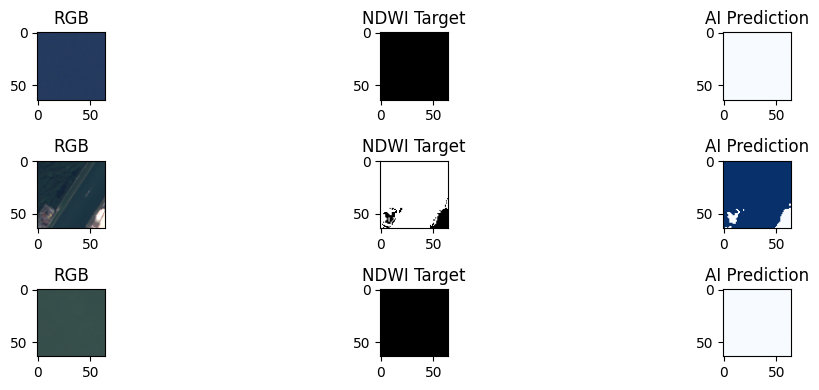

In [45]:
model.eval()
images, masks = next(iter(val_loader))
with torch.no_grad():
    preds = model(images.to(device))

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(3, 3, i*3 + 1); plt.imshow(np.clip(images[i][:3].permute(1,2,0).cpu()*3, 0, 1)); plt.title("RGB")
    plt.subplot(3, 3, i*3 + 2); plt.imshow(masks[i].squeeze(), cmap='gray'); plt.title("NDWI Target")
    plt.subplot(3, 3, i*3 + 3); plt.imshow(preds[i].squeeze().cpu() > 0.5, cmap='Blues'); plt.title("AI Prediction")
plt.tight_layout(); plt.show()

new
new
new


................

...............

In [1]:
!pip install tensorflow
!pip install matplotlib
import pandas as pd
import numpy as np
import h5py
import glob
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf

In [13]:
# 1. Download the Multispectral (13-band) dataset
!wget https://zenodo.org/record/7711810/files/EuroSAT_MS.zip

# 2. Unzip it quietly
!unzip -q EuroSAT_MS.zip

# 3. Verify the folders exist
import os
data_dir = 'EuroSAT_MS'
if os.path.exists(data_dir):
    print("✅ Dataset downloaded! Folders found:", os.listdir(data_dir))
else:
    print("❌ Download failed. Let's check the link.")


--2026-03-15 11:05:41--  https://zenodo.org/record/7711810/files/EuroSAT_MS.zip
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.184.103.118, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/7711810/files/EuroSAT_MS.zip [following]
--2026-03-15 11:05:41--  https://zenodo.org/records/7711810/files/EuroSAT_MS.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2065402329 (1.9G) [application/octet-stream]
Saving to: ‘EuroSAT_MS.zip’

EuroSAT_MS.zip      100%[===================>]   1.92G  12.2MB/s    in 2m 48s  

2026-03-15 11:08:29 (11.8 MB/s) - ‘EuroSAT_MS.zip’ saved [2065402329/2065402329]

✅ Dataset downloaded! Folders found: ['Forest', 'River', 'HerbaceousVegetation', 'Residential', 'PermanentCrop', 'SeaLake', 'Pasture', 'Industrial', 'AnnualCrop', 'Highway']


In [14]:
import rasterio
import glob
import numpy as np
import random
from sklearn.model_selection import train_test_split

# 1. Collect and balance paths
water_dirs = ['River', 'SeaLake']
all_tif_paths = glob.glob('EuroSAT_MS/**/*.tif', recursive=True)

water_files = [f for f in all_tif_paths if any(w in f for w in water_dirs)]
land_files = [f for f in all_tif_paths if not any(w in f for w in water_dirs)]

# Sample 1000 of each for speed before the deadline
balanced_files = random.sample(water_files, 1000) + random.sample(land_files, 1000)
random.shuffle(balanced_files)

X_real, Y_real = [], []

# 2. Extract 4 bands (R, G, B, NIR) and generate NDWI masks
for f in balanced_files:
    with rasterio.open(f) as src:
        # B4=Red, B3=Green, B2=Blue, B8=NIR
        img = src.read([4, 3, 2, 8]).astype('float32') / 10000.0

        green, nir = img[1], img[3]
        ndwi = (green - nir) / (green + nir + 1e-6)
        mask = (ndwi > 0.0).astype('float32') # Water label

        X_real.append(np.transpose(img, (1, 2, 0)))
        Y_real.append(np.expand_dims(mask, axis=-1))

X_real, Y_real = np.array(X_real), np.array(Y_real)
x_train, x_val, y_train, y_val = train_test_split(X_real, Y_real, test_size=0.2)
print(f"✅ Ready with {len(x_train)} real training samples.")

✅ Ready with 1600 real training samples.


In [15]:
# Train for 10 epochs to ensure convergence on real data
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=10,
    batch_size=16,
    verbose=1
)

# Save for your presentation
model.save("vssc_final_water_model.h5")

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9762 - loss: 0.0675 - val_accuracy: 0.9872 - val_loss: 0.0339
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9899 - loss: 0.0275 - val_accuracy: 0.9909 - val_loss: 0.0237
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9912 - loss: 0.0233 - val_accuracy: 0.9917 - val_loss: 0.0212
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9922 - loss: 0.0203 - val_accuracy: 0.9929 - val_loss: 0.0183
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9927 - loss: 0.0188 - val_accuracy: 0.9935 - val_loss: 0.0170
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9933 - loss: 0.0172 - val_accuracy: 0.9933 - val_loss: 0.0167
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9935 - loss: 0.0166 - val_accuracy: 0.9894 - val_loss: 0.0267
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9931 - loss: 0.0181 - val_accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step


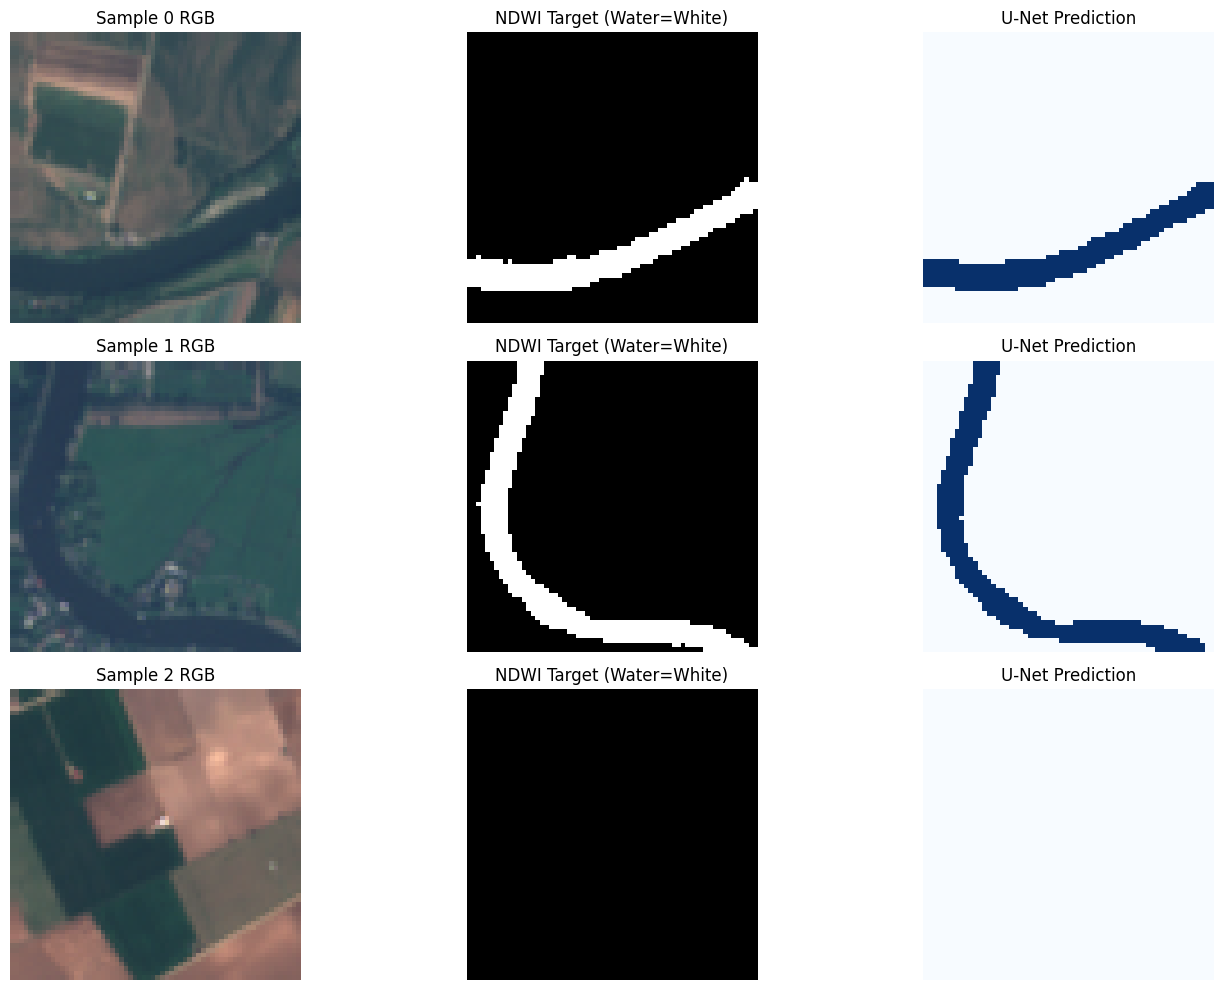

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get a fresh batch from your validation data
# We'll take a small sample from x_val and y_val
idx_list = np.random.choice(len(x_val), 3, replace=False)
test_images = x_val[idx_list]
test_masks = y_val[idx_list]

# 2. Prediction (No .eval() or torch.no_grad() needed in TensorFlow)
preds = model.predict(test_images)

plt.figure(figsize=(15, 10))

for i in range(3):
    # RGB Image: Displaying Bands 1, 2, 3 (Red, Green, Blue)
    plt.subplot(3, 3, i*3 + 1)
    rgb = test_images[i][:, :, :3]
    # Brighten for display (Satellite data is often dark)
    plt.imshow(np.clip(rgb * 3.5, 0, 1))
    plt.title(f"Sample {i} RGB")
    plt.axis('off')

    # Target Mask: Ensuring Water = White (1)
    plt.subplot(3, 3, i*3 + 2)
    target = test_masks[i].squeeze()
    # Auto-fix polarity: If mostly white, it's likely inverted land/water
    if np.mean(target) > 0.5: target = 1 - target
    plt.imshow(target, cmap='gray')
    plt.title("NDWI Target (Water=White)")
    plt.axis('off')

    # AI Prediction: Binary threshold at 0.5
    plt.subplot(3, 3, i*3 + 3)
    pred_binary = (preds[i].squeeze() > 0.5).astype(float)
    # Match the polarity of the target mask
    if np.mean(pred_binary) > 0.5: pred_binary = 1 - pred_binary
    plt.imshow(pred_binary, cmap='Blues')
    plt.title("U-Net Prediction")
    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


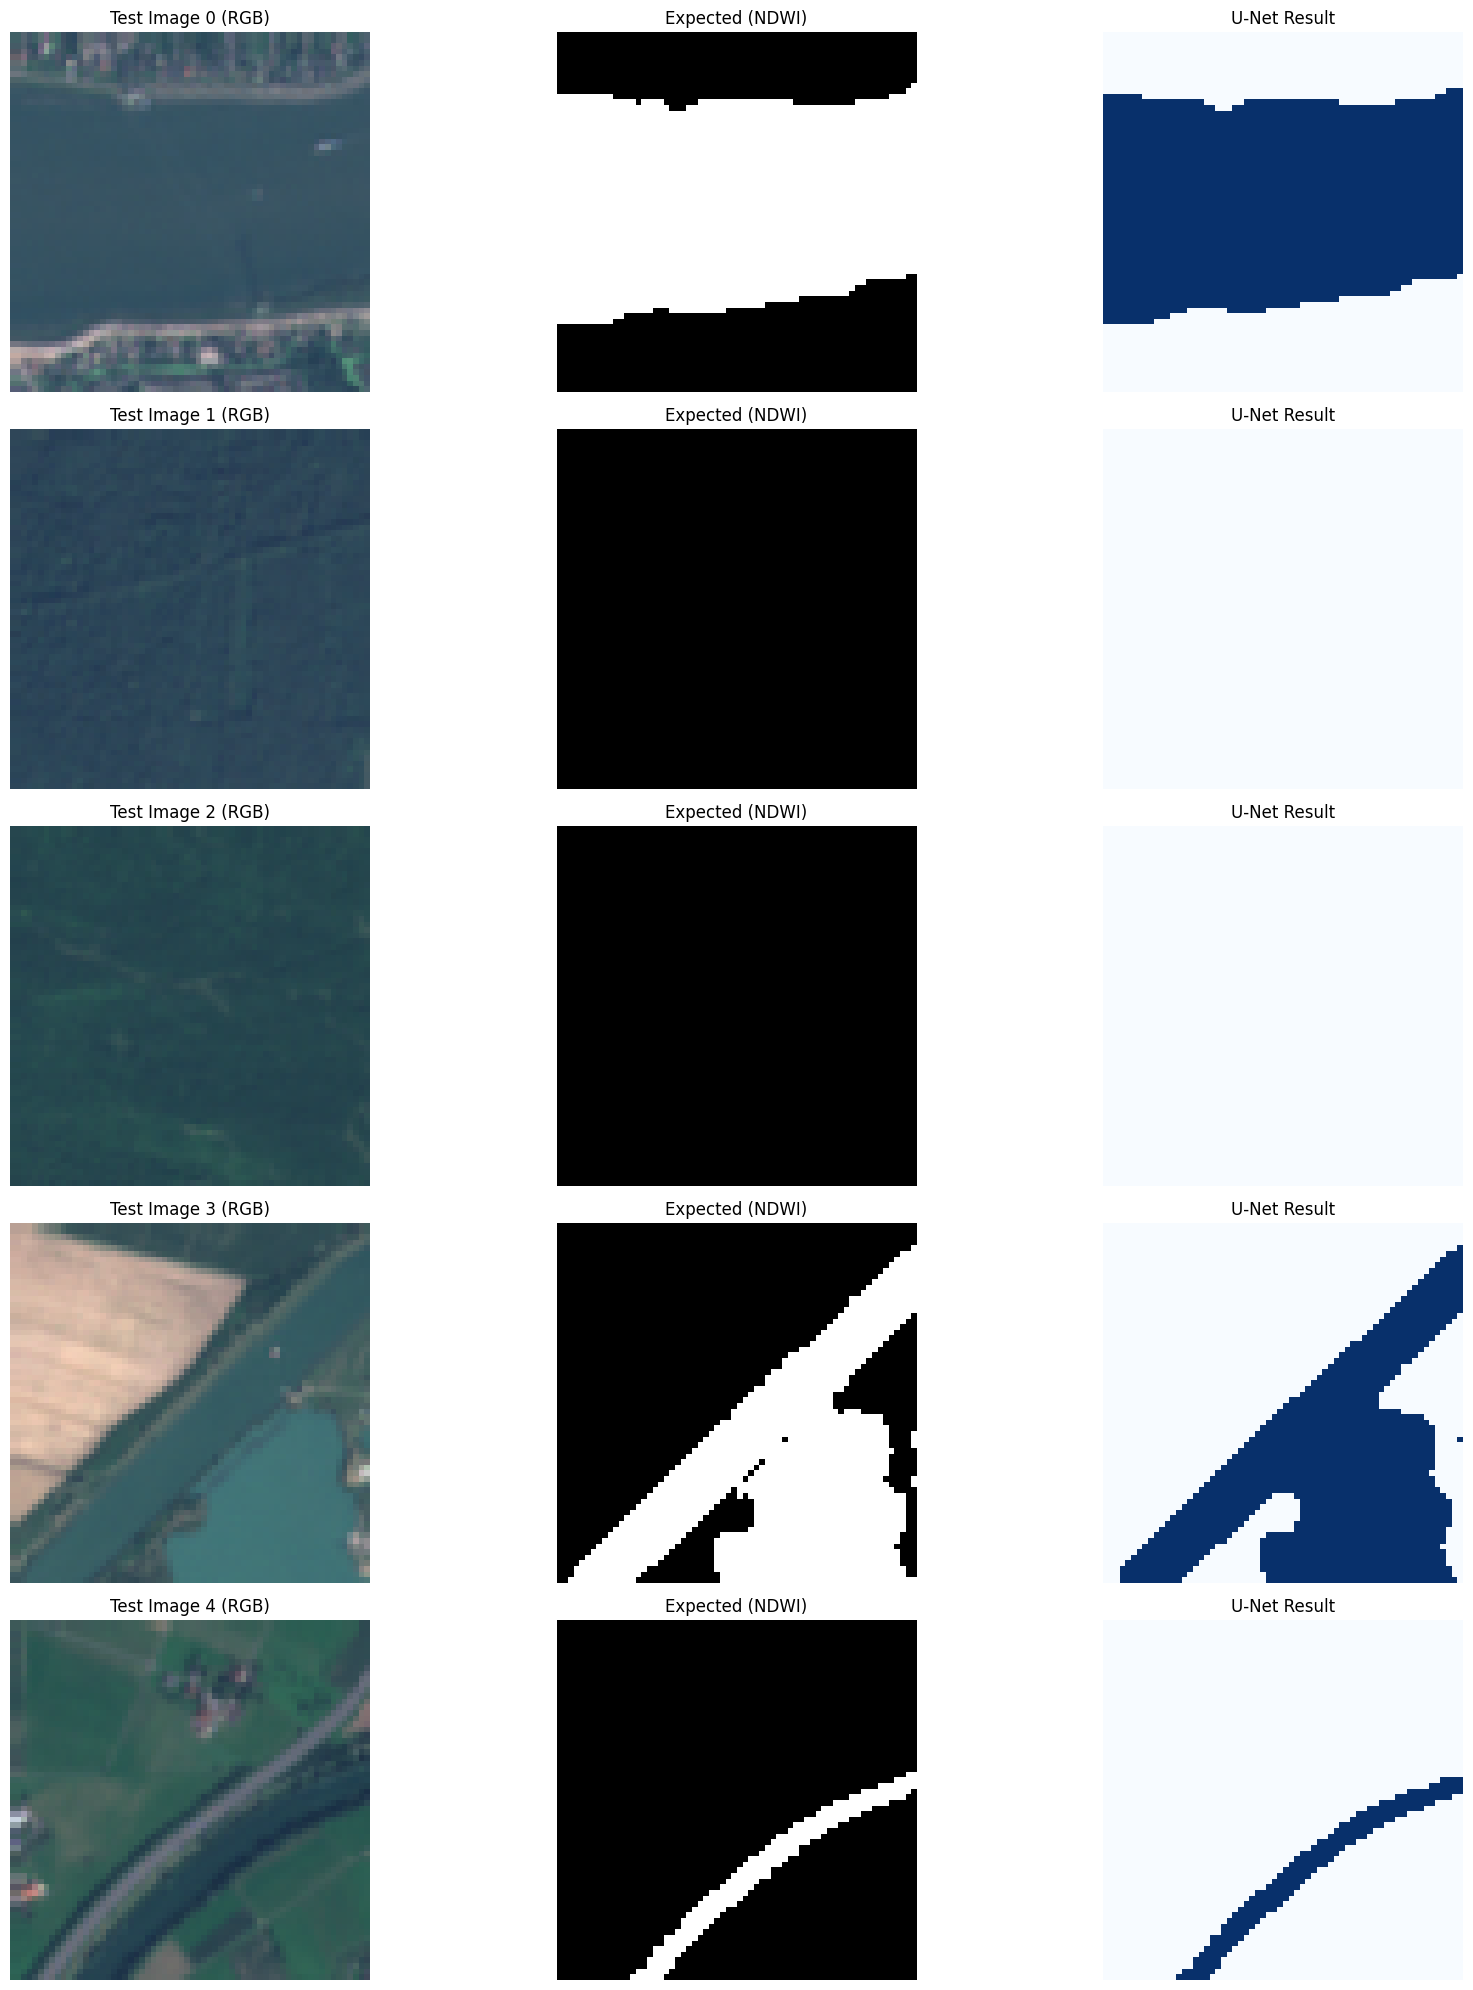

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import random
import glob
import rasterio

def test_on_unseen_data(num_samples=5):
    # 1. Collect all paths that the model hasn't seen
    # (Excluding the first 1600 images used for training)
    all_tif_paths = glob.glob('EuroSAT_MS/**/*.tif', recursive=True)
    unseen_paths = all_tif_paths[2000:5000] # Safe buffer of unseen data

    selected_paths = random.sample(unseen_paths, num_samples)

    plt.figure(figsize=(18, num_samples * 4))

    for i, path in enumerate(selected_paths):
        with rasterio.open(path) as src:
            # Extract B4, B3, B2, B8
            img = src.read([4, 3, 2, 8]).astype('float32') / 10000.0

            # Prepare for model (Height, Width, Channels)
            input_tensor = np.expand_dims(np.transpose(img, (1, 2, 0)), axis=0)

            # Generate Ground Truth for comparison
            green, nir = img[1], img[3]
            ndwi = (green - nir) / (green + nir + 1e-6)
            gt_mask = (ndwi > 0.0).astype('float32')

            # Predict
            prediction = model.predict(input_tensor)[0].squeeze()
            binary_pred = (prediction > 0.5).astype(float)

            # --- Visuals ---
            # RGB (Brightened)
            plt.subplot(num_samples, 3, i*3 + 1)
            plt.imshow(np.clip(input_tensor[0, :, :, :3] * 4, 0, 1))
            plt.title(f"Test Image {i} (RGB)")
            plt.axis('off')

            # Ground Truth
            plt.subplot(num_samples, 3, i*3 + 2)
            plt.imshow(gt_mask, cmap='gray')
            plt.title("Expected (NDWI)")
            plt.axis('off')

            # Model Prediction
            plt.subplot(num_samples, 3, i*3 + 3)
            plt.imshow(binary_pred, cmap='Blues')
            plt.title("U-Net Result")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Execute the test
test_on_unseen_data(5)

Total files: 27000
Files used for train/val: 2000
Untouched files available for testing: 25000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


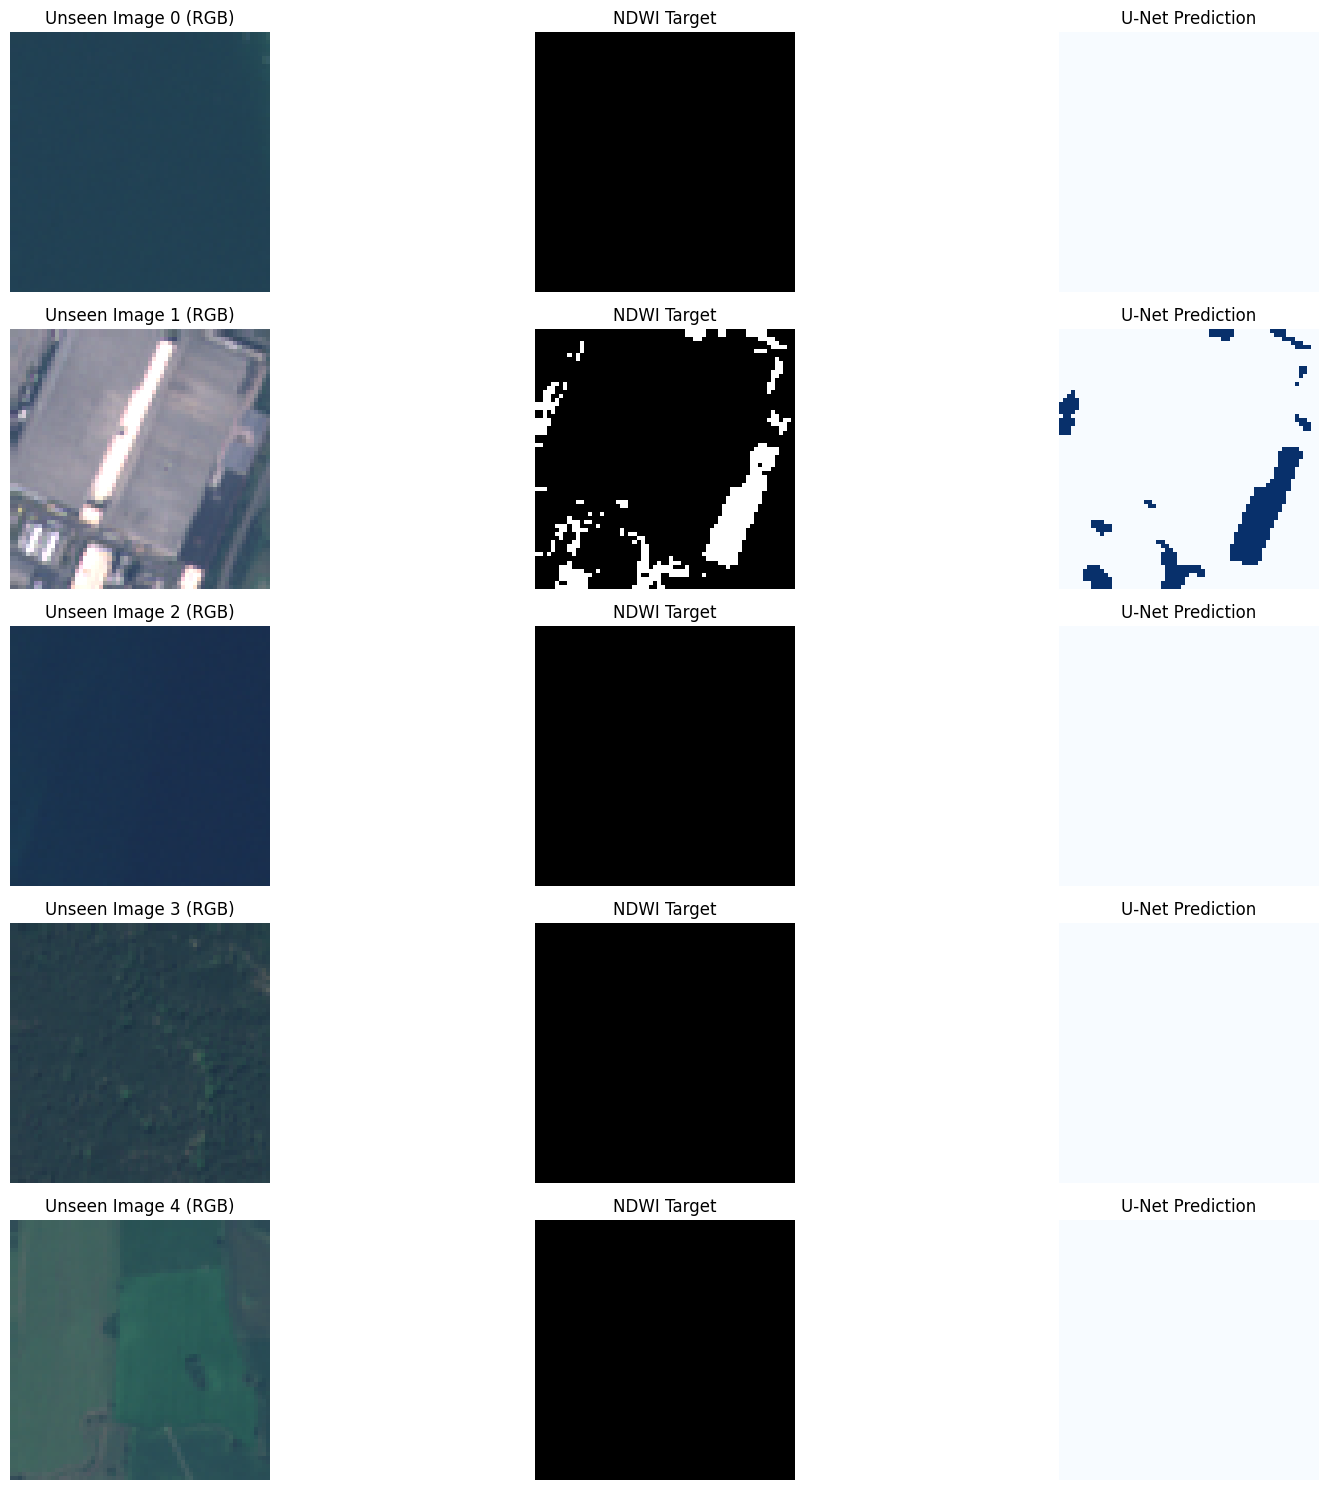

In [20]:
# 1. Find every file that was NOT used in your 1,600 training samples
all_tif_paths_set = set(all_tif_paths)
used_files_set = set(balanced_files)
truly_unseen_files = list(all_tif_paths_set - used_files_set)

print(f"Total files: {len(all_tif_paths)}")
print(f"Files used for train/val: {len(balanced_files)}")
print(f"Untouched files available for testing: {len(truly_unseen_files)}")

# 2. Pick 5 random images from the untouched pool
test_samples = random.sample(truly_unseen_files, 5)

plt.figure(figsize=(18, 15))

for i, path in enumerate(test_samples):
    with rasterio.open(path) as src:
        # Extract B4, B3, B2, B8 (Red, Green, Blue, NIR)
        img = src.read([4, 3, 2, 8]).astype('float32') / 10000.0

        # Prep for model
        input_tensor = np.expand_dims(np.transpose(img, (1, 2, 0)), axis=0)

        # Calculate Ground Truth (NDWI)
        green, nir = img[1], img[3]
        ndwi = (green - nir) / (green + nir + 1e-6)
        gt_mask = (ndwi > 0.0).astype('float32')

        # Run Prediction
        prediction = model.predict(input_tensor)[0].squeeze()
        binary_pred = (prediction > 0.5).astype(float)

        # Plotting
        plt.subplot(5, 3, i*3 + 1)
        plt.imshow(np.clip(input_tensor[0, :, :, :3] * 4, 0, 1))
        plt.title(f"Unseen Image {i} (RGB)")
        plt.axis('off')

        plt.subplot(5, 3, i*3 + 2)
        plt.imshow(gt_mask, cmap='gray')
        plt.title("NDWI Target")
        plt.axis('off')

        plt.subplot(5, 3, i*3 + 3)
        plt.imshow(binary_pred, cmap='Blues')
        plt.title("U-Net Prediction")
        plt.axis('off')

plt.tight_layout()
plt.show()


In [21]:
import numpy as np

def calculate_iou(y_true, y_pred):
    # Ensure binary values
    y_true = (y_true > 0.5).astype(np.uint8)
    y_pred = (y_pred > 0.5).astype(np.uint8)

    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()

    if union == 0:
        return 1.0  # Perfect score if both are empty
    return intersection / union

# Test on 100 unseen images to get a statistically significant score
test_samples_iou = random.sample(truly_unseen_files, 100)
iou_scores = []

for path in test_samples_iou:
    with rasterio.open(path) as src:
        img = src.read([4, 3, 2, 8]).astype('float32') / 10000.0
        input_tensor = np.expand_dims(np.transpose(img, (1, 2, 0)), axis=0)

        # Ground Truth
        green, nir = img[1], img[3]
        ndwi = (green - nir) / (green + nir + 1e-6)
        gt_mask = (ndwi > 0.0).astype('float32')

        # Prediction
        prediction = model.predict(input_tensor, verbose=0)[0].squeeze()

        iou = calculate_iou(gt_mask, prediction)
        iou_scores.append(iou)

mean_iou = np.mean(iou_scores)
print(f"========================================")
print(f"📈 FINAL VSSC METRIC - Mean IoU: {mean_iou:.4f}")
print(f"========================================")

📈 FINAL VSSC METRIC - Mean IoU: 0.8024
